# Figure development for scRNA-seq and spatial data

`scanpy`/`squidpy`'s default plots are built for fast exploration, not for a poster, slide deck, or publication figure. This notebook takes a plot from its scanpy default to something presentation-ready, one change at a time:

- **Colorblind-safe color** - a published categorical palette (Okabe-Ito) for cluster labels, and perceptually-uniform colormaps (viridis/cividis) for continuous expression values
- **Transparent backgrounds** - so a figure drops cleanly onto a colored slide or poster background
- **Spacing and decluttering** - removing default chrome (borders, excess whitespace) that adds noise without information
- **Complex composite figures** - combining several panels (UMAP + violin + dotplot, or several spatial genes) into one figure with a shared, consistent style
- **Interactive alternatives** - the same data as an explorable Plotly figure, for when a static image isn't enough

We apply this progression twice: once to a scRNA-seq UMAP (Part A), and once to a spatial plot (Part B), reusing the same PBMC3k and Visium lymph node samples from the earlier notebooks in this series.

How to use this Google Colab

- Select Python as the programming language: Click "Runtime -> Change runtime type", then ensure "Runtime type" is set to "Python".
- Click the "Connect" button on the top-right corner. Now, you are ready to run the tutorial.

# **1. Install and import packages**

In [1]:
# Install required python packages (takes ~2-3 min)
!uv pip install scanpy==1.11.2 squidpy==1.6.5 igraph==0.11.8 leidenalg==0.10.2 plotly==5.24.1 kaleido==0.2.1 pillow seaborn==0.13.2

# import the python packages
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from PIL import Image
import warnings

warnings.filterwarnings("ignore")
sc.settings.verbosity = 1

Using Python 3.13.15 environment at: /usr
Resolved 118 packages in 8.79s
Prepared 39 packages in 8.92s
Uninstalled 2 packages in 123ms
Installed 39 packages in 301ms
 + aiobotocore==2.26.0
 + aioitertools==0.13.0
 + anndata==0.12.19
 + array-api-compat==1.15.0
 + asciitree==0.3.3
 + botocore==1.41.5
 - dask==2026.8.0
 + dask==2024.11.2
 + dask-image==2026.5.0
 + datashader==0.19.1
 + deprecated==3.0.0
 + docrep==0.3.2
 + fasteners==0.20
 + igraph==0.11.8
 + jmespath==1.1.0
 + kaleido==0.2.1
 + legacy-api-wrap==1.5
 + leidenalg==0.10.2
 + matplotlib-scalebar==0.9.0
 + multiscale-spatial-image==2.0.3
 + numcodecs==0.15.1
 + ome-zarr==0.11.1
 + omnipath==1.0.12
 + pims==0.7
 + pyct==0.6.0
 + s3fs==2025.12.0
 + scanpy==1.11.2
 + scverse-misc==0.1.6
 + session-info2==0.4.2
 + slicerator==1.1.0
 + spatial-image==1.2.3
 + spatialdata==0.5.0
 + squidpy==1.6.5
 + texttable==1.7.0
 + validators==0.35.0
 - wrapt==2.4.1
 + wrapt==1.17.3
 + xarray-dataclass==3.0.0
 + xarray-schema==0.0.3
 + xarray-

/usr/local/lib/python3.13/dist-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/usr/local/lib/python3.13/dist-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/usr/local/lib/python3.13/dist-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/usr/local/lib/python3.13/dist-packages/leidenalg/VertexPartition.py:413: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\frac{1}{m} \\sum_{ij} \\left(A_{ij} - \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/usr/local/lib/python3.13/dist-packages/leidenalg/VertexPartition.py:788: SyntaxWarn

## 1.1 A colorblind-safe palette we'll reuse throughout

[Okabe & Ito (2008)](https://jfly.uni-koeln.de/color/) is a widely used 8-color categorical palette designed to remain distinguishable under the common forms of color vision deficiency. We define it once here as plain hex codes and reuse it for every categorical (cluster/cell-type) plot below. For continuous values (gene expression, counts), we use `"viridis"` and `"cividis"` - both perceptually uniform and colorblind-safe, and both already built into matplotlib.

In [2]:
# Okabe-Ito categorical palette (colorblind-safe), as hex codes
OKABE_ITO = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#000000",  # black
]

# A perceptually-uniform, colorblind-safe sequential colormap for continuous values
CONTINUOUS_CMAP = "viridis"

def categorical_palette(n):
    """Cycle the Okabe-Ito palette if there are more categories than colors."""
    return [OKABE_ITO[i % len(OKABE_ITO)] for i in range(n)]

def add_panel_label(ax, label, x=-0.12, y=1.08):
    """Bold panel letter (A, B, C, ...) placed just outside the top-left of an axis,
    the way multi-panel figures are labeled in most journals."""
    ax.text(x, y, label, transform=ax.transAxes, fontsize=16, fontweight="bold", va="bottom", ha="right")


# **2. Part A: Developing a scRNA-seq figure (PBMC3k)**

## 2.1 Quick load and process

Condensed preprocessing - see the cell type annotation notebook in this series for the fully explained version of these same steps.

In [3]:
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers["lognorm"] = adata.X.copy()

sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata.raw = adata
adata = adata[:, adata.var.highly_variable].copy()
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=30)
sc.pp.neighbors(adata)
sc.tl.leiden(adata, flavor="igraph", n_iterations=-1, resolution=0.5)
sc.tl.umap(adata)

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

## 2.2 The scanpy default

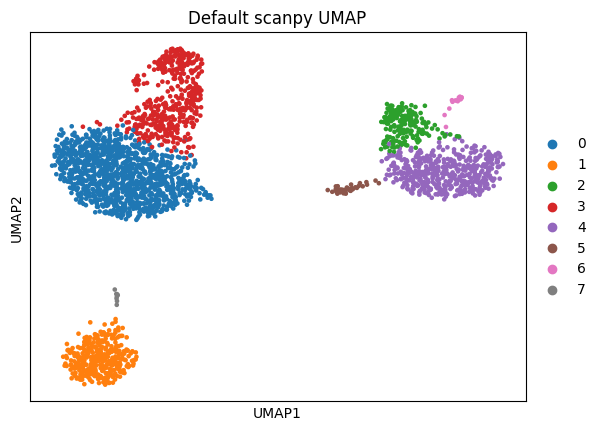

In [4]:
sc.pl.umap(adata, color="leiden", title="Default scanpy UMAP")

This is a perfectly good plot for exploring your own data, but it has a few things worth reconsidering for a figure someone else will look at: the default `tab20`-style palette is not colorblind-safe once you have more than a handful of categories, the plot always renders on a solid white background, and there is a visible bounding box around the axes that adds a border without adding information.

## 2.3 Colorblind-safe color

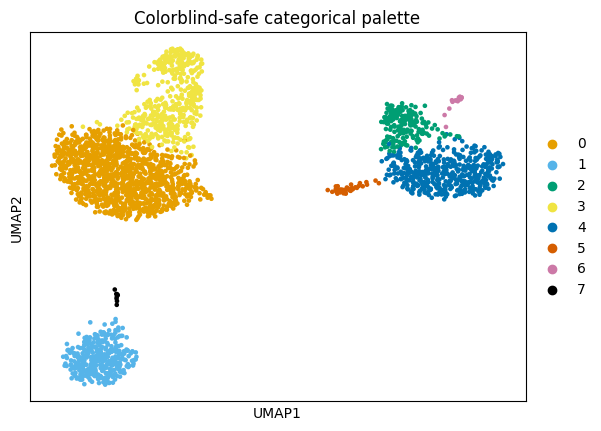

In [5]:
n_clusters = adata.obs["leiden"].nunique()
cluster_palette = categorical_palette(n_clusters)

sc.pl.umap(adata, color="leiden", palette=cluster_palette, title="Colorblind-safe categorical palette")

For a *continuous* value like a single gene's expression, a categorical palette doesn't apply - use a perceptually uniform sequential colormap instead, so that equal steps in expression look like equal steps in color.

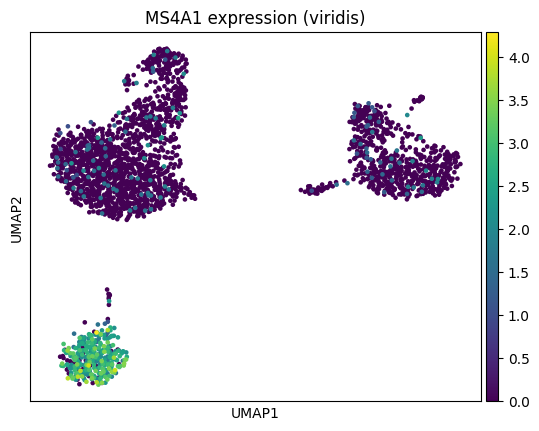

In [6]:
sc.pl.umap(adata, color="MS4A1", cmap=CONTINUOUS_CMAP, title="MS4A1 expression (viridis)")

## 2.4 Transparent backgrounds

Setting a figure's background to transparent only matters once you save it - Jupyter's inline display always renders on white, so the effect is invisible until you export. We save two versions and composite the transparent one onto a colored canvas with `PIL` to actually see the difference here, rather than just taking it on faith.

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.umap(adata, color="leiden", palette=cluster_palette, ax=ax, show=False, frameon=False, title="")

# transparent=True clears both the figure and axes background when saving
fig.savefig("umap_transparent.png", dpi=150, transparent=True, bbox_inches="tight")
fig.savefig("umap_opaque.png", dpi=150, transparent=False, bbox_inches="tight")
plt.close(fig)

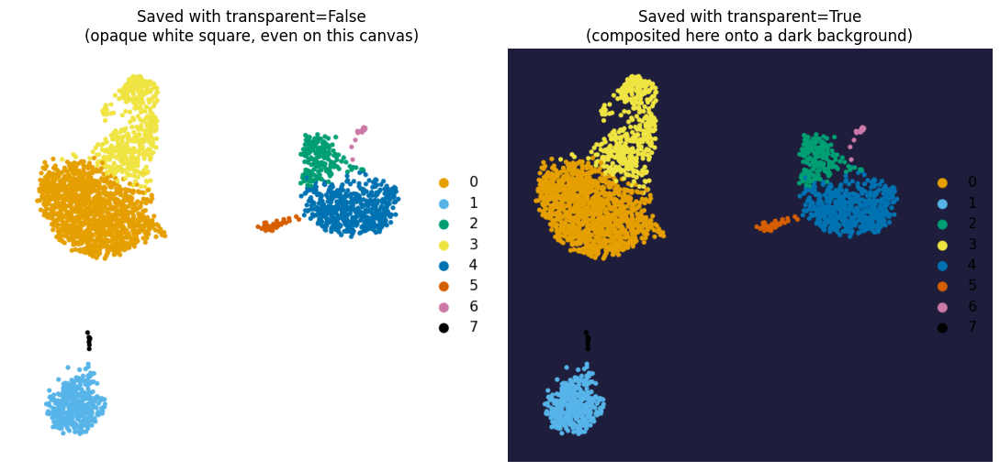

In [8]:
# Composite the transparent PNG onto a colored background to prove the alpha channel is real
canvas_color = (30, 30, 60)  # a dark navy "slide background"
transparent_png = Image.open("umap_transparent.png").convert("RGBA")
canvas = Image.new("RGBA", transparent_png.size, canvas_color + (255,))
canvas.alpha_composite(transparent_png)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
axes[0].imshow(Image.open("umap_opaque.png"))
axes[0].set_title("Saved with transparent=False\n(opaque white square, even on this canvas)")
axes[0].axis("off")
axes[1].imshow(canvas)
axes[1].set_title("Saved with transparent=True\n(composited here onto a dark background)")
axes[1].axis("off")
plt.tight_layout()

## 2.5 Spacing and decluttering

A few small changes remove chrome that scanpy adds by default but that a finished figure usually doesn't need: the axes bounding box (`frameon=False`), the tiny UMAP axis arrows, and any excess whitespace around the figure on save (`bbox_inches="tight"`). `sc.set_figure_params` applies sensible defaults - like a higher save DPI - to every plot for the rest of the session, instead of repeating the same arguments on every call.

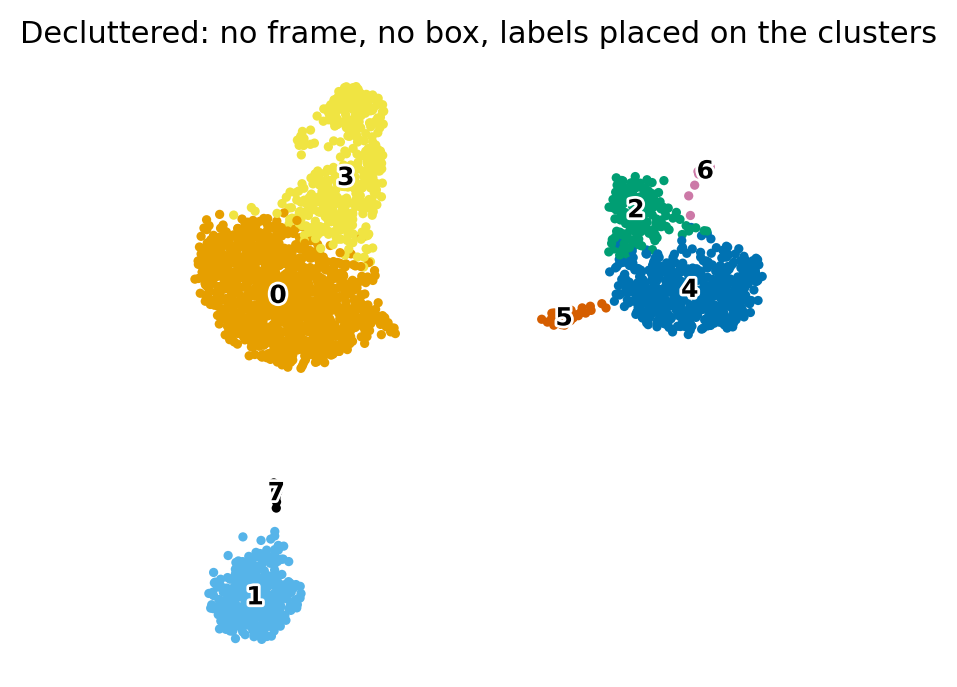

In [9]:
sc.set_figure_params(dpi=100, dpi_save=300, facecolor="white", frameon=False, fontsize=11)

sc.pl.umap(
    adata,
    color="leiden",
    palette=cluster_palette,
    legend_loc="on data",
    legend_fontsize=9,
    legend_fontoutline=2,
    title="Decluttered: no frame, no box, labels placed on the clusters",
)

## 2.6 Quick cell type labels

The complex figure below reads better with real cell type names than with cluster numbers. We reuse the same lightweight marker-scoring approach as the cell type annotation notebook in this series (see that notebook for the full walkthrough): score each cluster against a small set of canonical PBMC marker genes and assign whichever type scores highest.

In [10]:
def assign_manual_celltypes(adata, marker_genes, groupby="leiden", use_raw=True, label="cell_type"):
    """Score each cell type's marker genes per cell, average within each cluster, and
    assign each cluster the cell type with the highest average score. Reused for both
    the scRNA-seq and the spatial sample below, so every figure downstream shares the
    same kind of label."""
    for name, genes in marker_genes.items():
        genes_present = [g for g in genes if g in (adata.raw.var_names if use_raw else adata.var_names)]
        sc.tl.score_genes(adata, genes_present, score_name=f"score_{name}", use_raw=use_raw)

    score_cols = [f"score_{name}" for name in marker_genes]
    cluster_scores = adata.obs.groupby(groupby)[score_cols].mean()
    cluster_scores.columns = list(marker_genes.keys())
    best_type_per_cluster = cluster_scores.idxmax(axis=1)

    adata.obs[label] = adata.obs[groupby].map(best_type_per_cluster).astype("category")

pbmc_marker_genes = {
    "CD4 T cells": ["IL7R", "CD3D", "CD3E"],
    "CD8 T cells": ["CD8A", "CD8B", "CD3D"],
    "B cells": ["MS4A1", "CD79A", "CD79B"],
    "NK cells": ["GNLY", "NKG7", "KLRD1"],
    "CD14+ Monocytes": ["CD14", "LYZ", "S100A8"],
    "FCGR3A+ Monocytes": ["FCGR3A", "MS4A7"],
    "Dendritic cells": ["FCER1A", "CST3"],
    "Megakaryocytes": ["PPBP", "PF4"],
}

assign_manual_celltypes(adata, pbmc_marker_genes)
cell_type_palette = categorical_palette(adata.obs["cell_type"].nunique())

## 2.7 A complex, paper-ready composite figure

Published multi-panel figures share a few conventions beyond individual plot styling: each panel is labeled with a bold letter (A, B, C, ...) so the text can refer to "Fig. 1B", axes carry clear labels rather than relying on a viewer to guess, and panels that summarize the same underlying data (a UMAP, a violin plot, a heatmap, a dotplot) are laid out together with one consistent color scheme. We build all four here with `matplotlib.gridspec`.

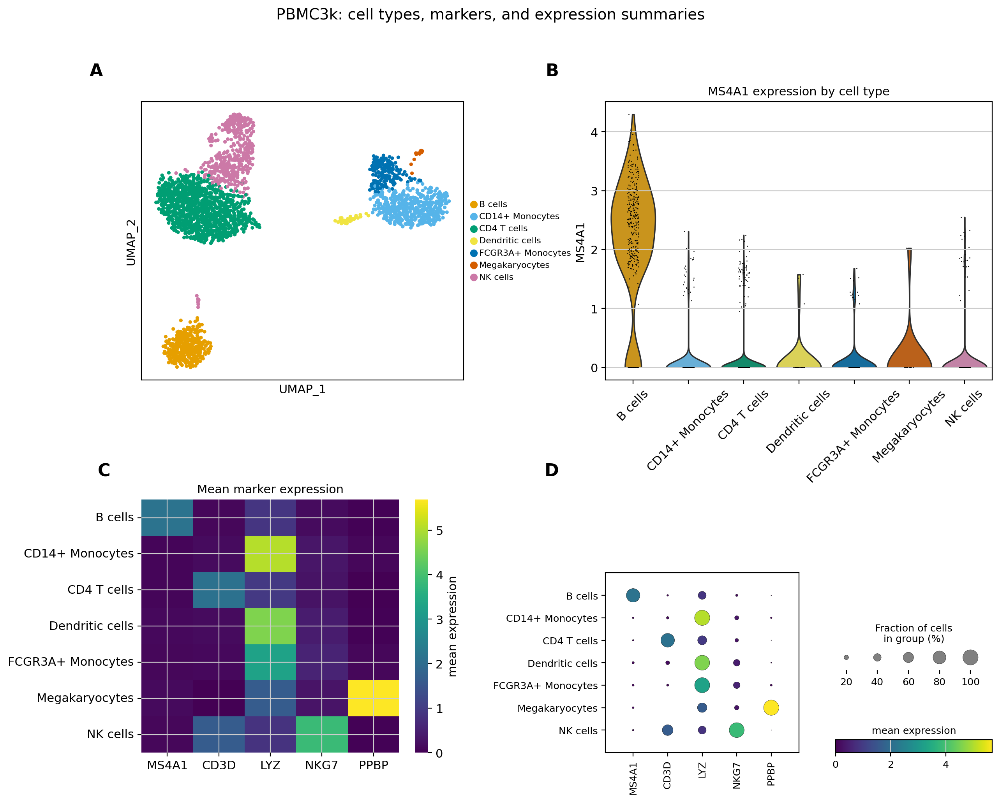

In [11]:
sc.tl.rank_genes_groups(adata, groupby="cell_type", use_raw=True, method="wilcoxon")

marker_genes = ["MS4A1", "CD3D", "LYZ", "NKG7", "PPBP"]

fig = plt.figure(figsize=(14, 11))
gs = gridspec.GridSpec(2, 2, height_ratios=[1.1, 1], width_ratios=[1, 1.2], hspace=0.45, wspace=0.4)

# Panel A: UMAP with cell type labels and explicit, publication-style axis labels.
# frameon=True brings back the boxed border around the axes (overriding the frameless
# default set globally in 2.5) - a common paper style is a visible box with axis labels
# but no tick numbers, since UMAP axes have no inherent scale.
ax_umap = fig.add_subplot(gs[0, 0])
sc.pl.umap(adata, color="cell_type", palette=cell_type_palette, ax=ax_umap, show=False, frameon=True, legend_loc="right margin", legend_fontsize=8, title="")
ax_umap.set_xlabel("UMAP_1")
ax_umap.set_ylabel("UMAP_2")
ax_umap.set_xticks([])
ax_umap.set_yticks([])
add_panel_label(ax_umap, "A")

# Panel B: one marker gene, distribution per cell type
ax_violin = fig.add_subplot(gs[0, 1])
sc.pl.violin(adata, keys="MS4A1", groupby="cell_type", ax=ax_violin, show=False, palette=cell_type_palette, rotation=45)
ax_violin.set_title("MS4A1 expression by cell type")
add_panel_label(ax_violin, "B")

# Panel C: mean expression of several markers per cell type, as a heatmap
mean_expr = sc.get.obs_df(adata, keys=marker_genes + ["cell_type"], use_raw=True).groupby("cell_type").mean()
ax_heatmap = fig.add_subplot(gs[1, 0])
sns.heatmap(mean_expr, cmap=CONTINUOUS_CMAP, ax=ax_heatmap, cbar_kws={"label": "mean expression"})
ax_heatmap.set_title("Mean marker expression")
ax_heatmap.set_ylabel("")
add_panel_label(ax_heatmap, "C")

# Panel D: the same markers, as a dotplot (expression level and percent-expressing at once)
ax_dot = fig.add_subplot(gs[1, 1])
sc.pl.dotplot(adata, var_names=marker_genes, groupby="cell_type", ax=ax_dot, show=False, cmap=CONTINUOUS_CMAP, colorbar_title="mean expression")
add_panel_label(ax_dot, "D")

fig.suptitle("PBMC3k: cell types, markers, and expression summaries", fontsize=14, y=1.02)
plt.show()

# **3. Part B: Developing a spatial figure (Visium lymph node)**

## 3.1 Quick load and process

In [12]:
adata_vis = sq.datasets.visium("V1_Human_Lymph_Node")
adata_vis.var_names_make_unique()

sc.pp.calculate_qc_metrics(adata_vis, inplace=True, percent_top=None)
sc.pp.filter_cells(adata_vis, min_counts=500)
sc.pp.filter_genes(adata_vis, min_cells=10)
sc.pp.normalize_total(adata_vis, target_sum=1e4)
sc.pp.log1p(adata_vis)

sc.pp.highly_variable_genes(adata_vis, n_top_genes=2000)
adata_vis.raw = adata_vis
adata_vis_hvg = adata_vis[:, adata_vis.var.highly_variable].copy()
sc.pp.scale(adata_vis_hvg, max_value=10)
sc.tl.pca(adata_vis_hvg, n_comps=30)
sc.pp.neighbors(adata_vis_hvg)
sc.tl.leiden(adata_vis_hvg, flavor="igraph", n_iterations=-1, resolution=0.5)
adata_vis.obs["leiden"] = adata_vis_hvg.obs["leiden"].values

  0%|          | 0.00/7.86M [00:00<?, ?B/s]

  0%|          | 0.00/29.3M [00:00<?, ?B/s]

## 3.2 The scanpy default

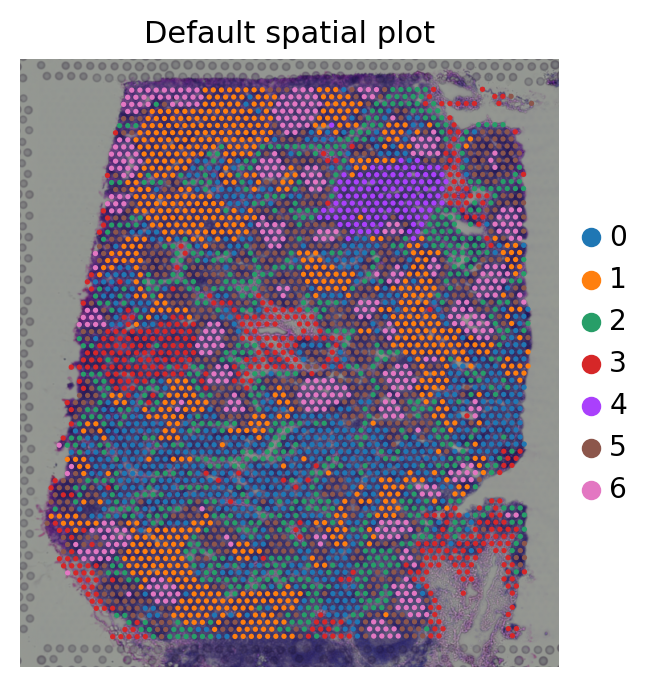

In [13]:
sc.pl.spatial(adata_vis, color="leiden", title="Default spatial plot")

## 3.3 The same palette and colormap choices, applied spatially

The exact same Okabe-Ito palette and viridis colormap we defined once in section 1.1 apply here without any change - deciding on a color scheme once and reusing it everywhere is itself a form of polish, since it makes multiple figures in the same document immediately feel consistent.

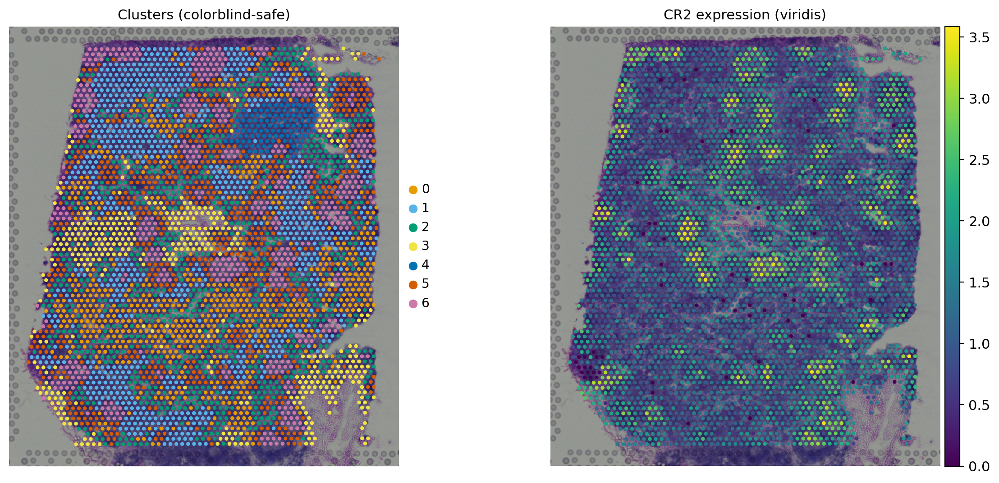

In [14]:
n_clusters_vis = adata_vis.obs["leiden"].nunique()
cluster_palette_vis = categorical_palette(n_clusters_vis)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
sc.pl.spatial(adata_vis, color="leiden", palette=cluster_palette_vis, ax=axes[0], show=False, frameon=False, title="Clusters (colorblind-safe)")
sc.pl.spatial(adata_vis, color="CR2", cmap=CONTINUOUS_CMAP, ax=axes[1], show=False, frameon=False, title="CR2 expression (viridis)")
plt.tight_layout()

## 3.4 Transparent background on a spatial plot

The same `savefig(..., transparent=True)` approach from 2.4 works identically here - spatial plots are still just a matplotlib figure with an image and a scatter overlay.

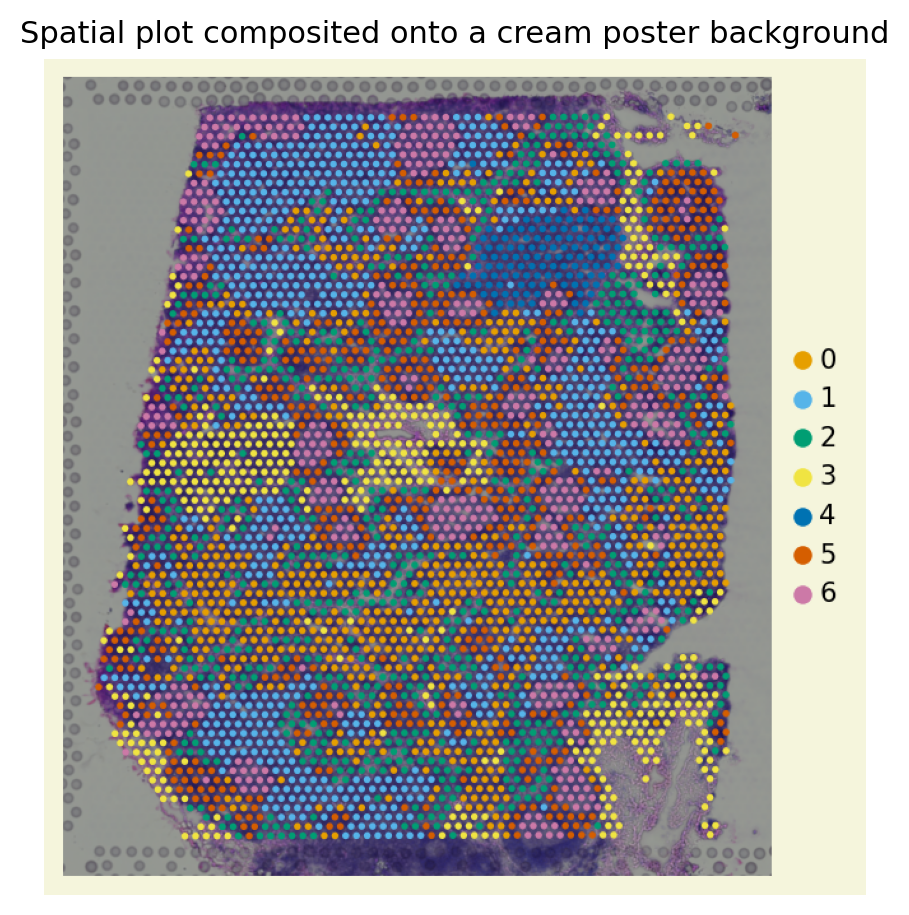

In [15]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
sc.pl.spatial(adata_vis, color="leiden", palette=cluster_palette_vis, ax=ax, show=False, frameon=False, title="")
fig.savefig("spatial_transparent.png", dpi=150, transparent=True, bbox_inches="tight")
plt.close(fig)

transparent_spatial = Image.open("spatial_transparent.png").convert("RGBA")
canvas_vis = Image.new("RGBA", transparent_spatial.size, (245, 245, 220, 255))  # a cream "poster background"
canvas_vis.alpha_composite(transparent_spatial)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(canvas_vis)
ax.axis("off")
ax.set_title("Spatial plot composited onto a cream poster background")
plt.show()

## 3.5 A complex spatial figure with a shared colorbar

When several panels show the same *kind* of value (here, expression of three different genes), giving each its own colorbar wastes space and makes the panels harder to compare - a reader has to check three separate scales instead of one. We fix the color scale to the same range across all three panels and share one colorbar for the whole figure.

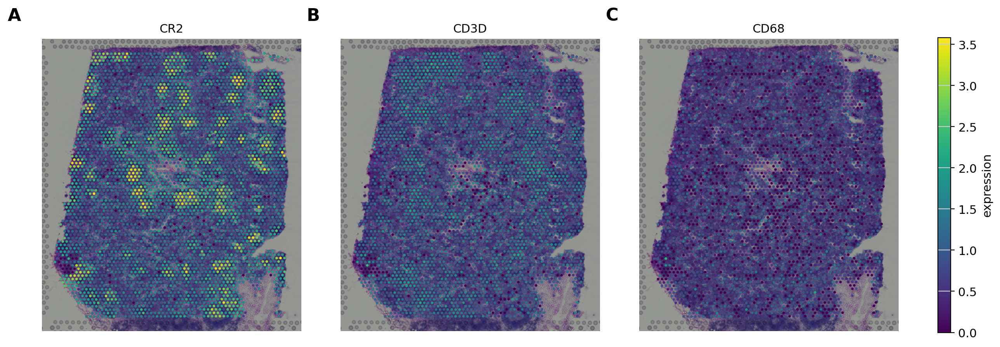

In [21]:
genes_to_show = ["CR2", "CD3D", "CD68"]
vmax = float(np.max([adata_vis[:, g].X.max() for g in genes_to_show]))
panel_letters = ["A", "B", "C"]

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.2)

axes_spatial = [fig.add_subplot(gs[0, i]) for i in range(3)]
for ax, gene, letter in zip(axes_spatial, genes_to_show, panel_letters):
    sc.pl.spatial(adata_vis, color=gene, cmap=CONTINUOUS_CMAP, vmin=0, vmax=vmax, ax=ax, show=False, frameon=False, colorbar_loc=None, title=gene)
    add_panel_label(ax, letter, x=-0.08, y=1.05)

# A single shared colorbar in its own thin axis, rather than one per panel
cax = fig.add_subplot(gs[0, 3])
sm = plt.cm.ScalarMappable(cmap=CONTINUOUS_CMAP, norm=plt.Normalize(vmin=0, vmax=vmax))
fig.colorbar(sm, cax=cax, label="expression")

#fig.suptitle("Three genes, one shared color scale", fontsize=13)
plt.show()

## 3.6 Quick cell type labels and a UMAP for the spatial sample

Spatial coordinates aren't the only embedding worth looking at - each spot also has a transcriptomic profile, so a UMAP of that profile is just as valid here as it was for the scRNA-seq data in Part A, and pairing the two views (spatial position and transcriptomic similarity) side by side is a very common panel combination in spatial papers. We reuse `assign_manual_celltypes` from 2.6 with a lymph-node-specific marker set, and compute a UMAP on the same HVG/PCA space already used for clustering.

In [17]:
lymph_node_marker_genes = {
    "T cell zone": ["CD3D", "CD3E", "CD2"],
    "B cell follicle": ["MS4A1", "CD79A", "CD19"],
    "Germinal center": ["MKI67", "AICDA", "BCL6"],
    "Plasma cells": ["MZB1", "IGHG1", "JCHAIN"],
    "Macrophages": ["CD68", "CD163"],
    "Follicular dendritic cells": ["CR2", "FDCSP"],
    "Endothelial": ["PECAM1", "VWF"],
}

assign_manual_celltypes(adata_vis_hvg, lymph_node_marker_genes, use_raw=True)
adata_vis.obs["cell_type"] = adata_vis_hvg.obs["cell_type"].values
cell_type_palette_vis = categorical_palette(adata_vis.obs["cell_type"].nunique())

# A UMAP of spot transcriptomes, reusing the neighbor graph already computed for clustering
sc.tl.umap(adata_vis_hvg)
adata_vis.obsm["X_umap"] = adata_vis_hvg.obsm["X_umap"]

## 3.7 A complex, paper-ready spatial figure

The same four-panel idea from 2.7 applies to spatial data with one addition: pairing the *spatial* view with the *transcriptomic* (UMAP) view of the same spots lets a reader confirm that clusters that look spatially organized are also transcriptomically distinct, not an artifact of position alone.

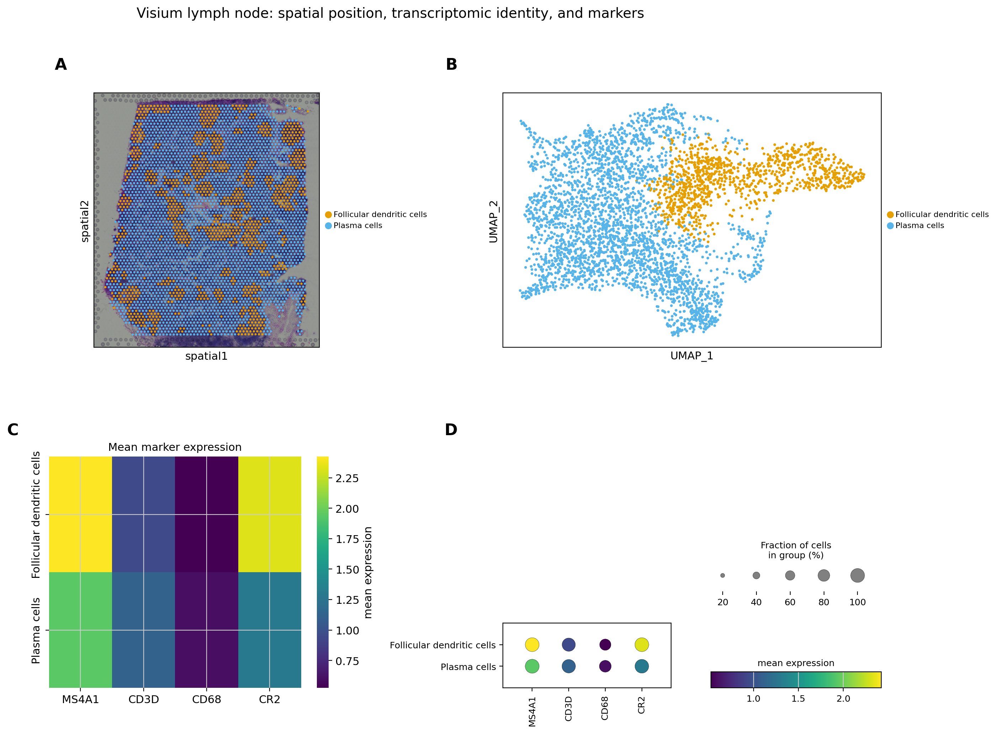

In [18]:
sc.tl.rank_genes_groups(adata_vis, groupby="cell_type", use_raw=False, method="wilcoxon")

spatial_marker_genes = ["MS4A1", "CD3D", "CD68", "CR2"]

fig = plt.figure(figsize=(15, 11))
gs = gridspec.GridSpec(2, 2, height_ratios=[1.1, 1], width_ratios=[1, 1.2], hspace=0.45, wspace=0.4)

# Panel A: cell types in their spatial position, boxed paper style
ax_spatial = fig.add_subplot(gs[0, 0])
sc.pl.spatial(adata_vis, color="cell_type", palette=cell_type_palette_vis, ax=ax_spatial, show=False, frameon=True, legend_loc="right margin", legend_fontsize=8, title="")
ax_spatial.set_xticks([])
ax_spatial.set_yticks([])
add_panel_label(ax_spatial, "A")

# Panel B: the same cell types in transcriptomic (UMAP) space
ax_umap_vis = fig.add_subplot(gs[0, 1])
sc.pl.embedding(adata_vis, basis="X_umap", color="cell_type", palette=cell_type_palette_vis, ax=ax_umap_vis, show=False, frameon=True, legend_loc="right margin", legend_fontsize=8, title="")
ax_umap_vis.set_xlabel("UMAP_1")
ax_umap_vis.set_ylabel("UMAP_2")
ax_umap_vis.set_xticks([])
ax_umap_vis.set_yticks([])
add_panel_label(ax_umap_vis, "B")

# Panel C: mean marker expression per cell type, as a heatmap
mean_expr_vis = sc.get.obs_df(adata_vis, keys=spatial_marker_genes + ["cell_type"], use_raw=False).groupby("cell_type").mean()
ax_heatmap_vis = fig.add_subplot(gs[1, 0])
sns.heatmap(mean_expr_vis, cmap=CONTINUOUS_CMAP, ax=ax_heatmap_vis, cbar_kws={"label": "mean expression"})
ax_heatmap_vis.set_title("Mean marker expression")
ax_heatmap_vis.set_ylabel("")
add_panel_label(ax_heatmap_vis, "C")

# Panel D: the same markers, as a dotplot
ax_dot_vis = fig.add_subplot(gs[1, 1])
sc.pl.dotplot(adata_vis, var_names=spatial_marker_genes, groupby="cell_type", ax=ax_dot_vis, show=False, use_raw=False, cmap=CONTINUOUS_CMAP, colorbar_title="mean expression")
add_panel_label(ax_dot_vis, "D")

fig.suptitle("Visium lymph node: spatial position, transcriptomic identity, and markers", fontsize=14, y=1.02)
plt.show()

# **4. Part C: Interactive figures with Plotly**

A static image is easy to drop into a slide or a paper, but a colleague exploring your data themselves often wants to hover over a point to see what it is, or zoom into a crowded region. [Plotly](https://plotly.com/python/) makes that possible with only a little more code than the static version, and the same colorblind-safe palette applies directly.

## 4.1 An interactive UMAP

In [19]:
umap_df = pd.DataFrame(adata.obsm["X_umap"], columns=["UMAP1", "UMAP2"], index=adata.obs_names)
umap_df["leiden"] = adata.obs["leiden"].values
umap_df["MS4A1"] = adata.raw[:, "MS4A1"].X.toarray().flatten()

fig = px.scatter(
    umap_df,
    x="UMAP1",
    y="UMAP2",
    color="leiden",
    color_discrete_sequence=cluster_palette,
    hover_data=["MS4A1"],
    title="Interactive UMAP - hover to inspect individual cells",
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(
    paper_bgcolor="rgba(0,0,0,0)",  # transparent figure background
    plot_bgcolor="rgba(0,0,0,0)",   # transparent plot area
    legend_title_text="Cluster",
)
fig.show()

## 4.2 An interactive spatial plot

The same idea applies to spot coordinates: plot the spatial x/y positions directly with Plotly, colored by whichever value you want to explore, and get hover/zoom for free. We flip the y-axis to match image coordinate conventions (row 0 at the top), which is otherwise a common source of an upside-down-looking spatial plot.

In [20]:
spatial_df = pd.DataFrame(adata_vis.obsm["spatial"], columns=["x", "y"], index=adata_vis.obs_names)
spatial_df["leiden"] = adata_vis.obs["leiden"].values
spatial_df["total_counts"] = adata_vis.obs["total_counts"].values

fig = px.scatter(
    spatial_df,
    x="x",
    y="y",
    color="leiden",
    color_discrete_sequence=cluster_palette_vis,
    hover_data=["total_counts"],
    title="Interactive spatial plot - hover to inspect individual spots",
)
fig.update_yaxes(autorange="reversed")  # match image row/column orientation
fig.update_traces(marker=dict(size=6))
fig.update_layout(paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)", legend_title_text="Cluster")
fig.show()

# **5. Wrap-up**

None of the changes in this notebook touch the underlying biology - every technique here is about how a result is *shown*, not what it says. A short checklist worth applying to any figure before it leaves your notebook:

- Are the categorical colors distinguishable under color vision deficiency (Okabe-Ito, or another published colorblind-safe palette), and is the colormap for continuous values perceptually uniform (viridis/cividis, not something like the old "jet")?
- Does the figure need a transparent background for where it's going (a slide, a poster), and did you actually check the saved file rather than just the inline preview?
- Is every border, box, and axis element on the figure adding information, or just left over from the default?
- If several panels show comparable values, would a shared color scale and colorbar make them easier to compare than one colorbar each?
- Would an interactive version help a collaborator explore the result themselves, in addition to (not instead of) the static figure for a document?

For further reading: [Okabe & Ito's original color universal design page](https://jfly.uni-koeln.de/color/), [matplotlib's guide to colormaps](https://matplotlib.org/stable/users/explain/colors/colormaps.html), and the [Plotly Python documentation](https://plotly.com/python/).